# Photon Trajectories in Kerr-like Wormhole Spacetime

Interactive 3D visualization of ray-traced photon trajectories.

**Parameters:** $a = 0.998$, $\bar\lambda = 0.9$, $\theta_0 = 80°$

**Model:** Full $\Delta_{WH}$ (Kerr with $M_\text{eff} = 1 + \bar\lambda^2 = 1.81$)

In [56]:
import numpy as np
import plotly.graph_objects as go

AXIS_LABEL_FONT_SIZE = 18
LEGEND_FONT_SIZE = 16

def load_ray(fname):
    """Load ray file: columns x y z timea sigmaa."""
    data = np.loadtxt(fname, comments='#')
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data

# Selected trajectories with diverse deflection behaviors
# ("only g_rr modified" model, critical alpha ~ -13.445 for beta=-5)
ray_files = [
    # mild deflection
    ('scan_fixed2/ray_a-18.00_b-5.0.txt',   'α = -18.00, β = -5.0'),
    # moderate deflection
    ('scan_fixed2/ray_a-15.00_b-5.0.txt',   'α = -15.00, β = -5.0'),
    # strong deflection (~0.55 orbits)
    ('scan_fixed2/ray_a-14.00_b-5.0.txt',   'α = -14.00, β = -5.0'),
    # near-critical spiral (~1.5 orbits)
    ('scan_fixed2/ray_a-13.1407_b-5.0.txt', 'α = -13.1407, β = -5.0'),
    # very near critical (~1.2 orbits)
    ('scan_fixed2/ray_a-13.0402_b-5.0.txt', 'α = -13.0402, β = -5.0'),
    # close approach (~0.9 orbits)
    ('scan_fixed2/ray_a-13.7437_b-5.0.txt', 'α = -13.7437, β = -5.0'),
]

# Physical parameters: M_eff = 1 + lambda_bar^2 = 1.81
r_throat = 3.32   # throat/outer horizon radius
r_sphere = 0.3 * r_throat  # central sphere radius for visualization
print(f'Loading {len(ray_files)} ray files...')
print(f'r_throat = {r_throat:.2f},  r_sphere = {r_sphere:.2f}')

Loading 6 ray files...
r_throat = 3.32,  r_sphere = 1.00


In [ ]:
fig = go.Figure()

# -- Central sphere at 0.3 × throat --
u = np.linspace(0, 2*np.pi, 40)
v = np.linspace(0, np.pi, 20)
bh_x = r_sphere * np.outer(np.cos(u), np.sin(v))
bh_y = r_sphere * np.outer(np.sin(u), np.sin(v))
bh_z = r_sphere * np.outer(np.ones_like(u), np.cos(v))

fig.add_trace(go.Surface(
    x=bh_x, y=bh_y, z=bh_z,
    colorscale=[[0, 'black'], [1, 'black']],
    showscale=False,
    name=f'Black Hole ({r_sphere:.1f} <i>r</i><sub>g</sub>)',
    opacity=1.0,
    hoverinfo='name',
))

# -- Throat ring (r = r_throat in equatorial plane) --
theta_ring = np.linspace(0, 2*np.pi, 100)
throat_x = r_throat * np.cos(theta_ring)
throat_y = r_throat * np.sin(theta_ring)
throat_z = np.zeros_like(theta_ring)

fig.add_trace(go.Scatter3d(
    x=throat_x, y=throat_y, z=throat_z,
    mode='lines',
    line=dict(color='green', width=3),
    name=f'Throat (<i>r</i> = {r_throat:.2f} <i>r</i><sub>g</sub>)',
    hoverinfo='name',
))

# -- Photon trajectories --
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#17becf']

for i, (fname, label) in enumerate(ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    
    # Clip to visible region for cleaner plot
    r = np.sqrt(x**2 + y**2 + z**2)
    mask = r < 30  # show only the near-BH portion
    
    fig.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='lines',
        line=dict(color=colors[i], width=3),
        name=label,
        hovertemplate='x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra>' + label + '</extra>',
    ))

# -- Layout --
fig.update_layout(
    title=dict(
        text='Photon trajectories in Kerr-like wormhole spacetime',
        x=0.5,
    ),
    scene=dict(
        xaxis=dict(title='<i>x</i> / <i>r</i><sub>g</sub>', range=[-8, 8]),
        yaxis=dict(title='<i>y</i> / <i>r</i><sub>g</sub>', range=[-10, 10]),
        zaxis=dict(title='<i>z</i> / <i>r</i><sub>g</sub>', range=[-5, 10]),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1.25, z=0.9),
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=0.8),
            up=dict(x=0, y=0, z=1),
        ),
    ),
    width=900,
    height=800,
    legend=dict(
        x=0.02, y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        font=dict(size=LEGEND_FONT_SIZE),
    ),
    margin=dict(l=0, r=0, t=60, b=0),
)

fig.show()

## Spiral-infall trajectories

Trajectories near the critical impact parameter that spiral multiple times
around the wormhole throat before falling in.

In [57]:
# --- Smoothness check utility ---
def check_smoothness(x, y, z):
    """Check trajectory smoothness. Returns max/mean turning angle in degrees."""
    dx, dy, dz = np.diff(x), np.diff(y), np.diff(z)
    norms = np.sqrt(dx**2 + dy**2 + dz**2)
    norms = np.maximum(norms, 1e-15)
    dirs = np.column_stack([dx/norms, dy/norms, dz/norms])
    dots = np.sum(dirs[:-1] * dirs[1:], axis=1)
    dots = np.clip(dots, -1, 1)
    angles = np.degrees(np.arccos(dots))
    return np.max(angles), np.mean(angles), angles

# Spiral-infall trajectories near critical alpha ("only g_rr modified" model)
# Critical alpha ~ -13.445 at beta=-5
spiral_ray_files = [
    # close approach (~0.9 orbits)
    ('scan_fixed2/ray_a-13.7437_b-5.0.txt', 'α = -13.7437, β = -5.0'),
    # near-critical spiral (~1.5 orbits)
    ('scan_fixed2/ray_a-13.1407_b-5.0.txt', 'α = -13.1407, β = -5.0'),
    # strong deflection (~1.2 orbits)
    ('scan_fixed2/ray_a-13.0402_b-5.0.txt', 'α = -13.0402, β = -5.0'),
]

# Verify smoothness of each trajectory
print('=== Smoothness verification ===')
for fname, label in spiral_ray_files:
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    max_ang, mean_ang, angles = check_smoothness(x, y, z)
    
    kinks = np.sum(angles > 5.0)
    phi = np.arctan2(y, x)
    dphi = np.diff(np.unwrap(phi))
    n_orbits = abs(np.sum(dphi)) / (2 * np.pi)
    r = np.sqrt(x**2 + y**2 + z**2)
    r_min = np.min(r)
    
    status = '✓ SMOOTH' if max_ang < 5.0 else '✗ HAS KINKS'
    print(f'  {label}')
    print(f'    {status}: max_angle={max_ang:.2f}°  mean_angle={mean_ang:.3f}°  kinks={kinks}')
    print(f'    orbits={n_orbits:.2f}  r_min={r_min:.2f}  npts={len(data)}')

=== Smoothness verification ===
  α = -13.7437, β = -5.0
    ✓ SMOOTH: max_angle=1.46°  mean_angle=0.083°  kinks=0
    orbits=0.93  r_min=3.43  npts=2865


  α = -13.1407, β = -5.0
    ✓ SMOOTH: max_angle=0.50°  mean_angle=0.060°  kinks=0
    orbits=1.46  r_min=4.74  npts=5553
  α = -13.0402, β = -5.0
    ✓ SMOOTH: max_angle=0.10°  mean_angle=0.054°  kinks=0
    orbits=1.24  r_min=4.96  npts=4915


In [60]:
# --- Combined interactive plot: original 6 + spiral trajectories ---
fig2 = go.Figure()

# Black hole
fig2.add_trace(go.Surface(
    x=bh_x, y=bh_y, z=bh_z,
    colorscale=[[0, 'black'], [1, 'black']],
    showscale=False, name=f'Black Hole ({r_sphere:.1f} <i>r</i><sub>g</sub>)',
    opacity=1.0, hoverinfo='name',
))

# Throat ring
fig2.add_trace(go.Scatter3d(
    x=throat_x, y=throat_y, z=throat_z,
    mode='lines', line=dict(color='green', width=3),
    name=f'Throat (<i>r</i> = {r_throat:.2f} <i>r</i><sub>g</sub>)', hoverinfo='name',
))

# Original 6 trajectories (dimmer)
orig_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#17becf']
for i, (fname, label) in enumerate(ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    mask = r < 30
    fig2.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='lines', line=dict(color=orig_colors[i], width=2),
        name=label, opacity=0.5,
        hovertemplate='x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra>' + label + '</extra>',
    ))

# Spiral trajectories (prominent)
spiral_colors = ['#e377c2', '#bcbd22', '#8c564b']
for i, (fname, label) in enumerate(spiral_ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    mask = r < 30
    fig2.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='lines', line=dict(color=spiral_colors[i], width=4),
        name=label,
        hovertemplate='x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra>' + label + '</extra>',
    ))

fig2.update_layout(
    title=dict(
        text='Photon trajectories: deflection + spiral-infall',
        x=0.5,
    ),
    scene=dict(
        xaxis=dict(title=dict(text='$x / r_g$', font=dict(size=AXIS_LABEL_FONT_SIZE)), range=[-8, 8]),
        yaxis=dict(title=dict(text='$y / r_g$', font=dict(size=AXIS_LABEL_FONT_SIZE)), range=[-10, 10]),
        zaxis=dict(title=dict(text='$z / r_g$', font=dict(size=AXIS_LABEL_FONT_SIZE)), range=[-5, 10]),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1.25, z=0.9),
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=0.8),
            up=dict(x=0, y=0, z=1),
        ),
    ),
    width=900, height=800,
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)', font=dict(size=LEGEND_FONT_SIZE)),
    margin=dict(l=0, r=0, t=60, b=0),
)

fig2.show()

In [6]:
# Save combined plot for comparison
fig2.write_image('plot_combined.png', width=900, height=800, scale=2)
print('Saved plot_combined.png')

Saved plot_combined.png


## 3D helical spiral-infall trajectories

Trajectories with large polar motion (high |β|): the photon wraps around
the spin axis *while* sweeping a large z-range, tracing a corkscrew that
falls toward the throat.

In [58]:
# --- 3D helical trajectories with different β values ("only g_rr modified" model) ---
helix_ray_files = [
    # helix (~1.4 orbits)
    ('scan_fixed2/ray_a-10.10_b-7.0.txt',   'α = -10.10, β = -7.0'),
    # helix (~0.8 orbits)
    ('scan_fixed2/ray_a-12.7387_b-7.0.txt', 'α = -12.7387, β = -7.0'),
    # wide helix (~0.9 orbits)
    ('scan_fixed2/ray_a-11.70_b-10.0.txt',  'α = -11.70, β = -10.0'),
]
helix_colors = ['#2ca02c', '#9467bd', '#e377c2']

# Verify smoothness
print('=== Smoothness + 3-D helix verification ===')
for fname, label in helix_ray_files:
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    max_ang, mean_ang, angles = check_smoothness(x, y, z)
    kinks = np.sum(angles > 5.0)

    phi_arr = np.unwrap(np.arctan2(y, x))
    n_orb = abs(phi_arr[-1] - phi_arr[0]) / (2 * np.pi)

    r = np.sqrt(x**2 + y**2 + z**2)
    near = r < 15
    z_range = z[near].max() - z[near].min() if np.any(near) else 0.0

    status = '✓ SMOOTH' if max_ang < 5.0 and kinks == 0 else '✗ HAS KINKS'
    print(f'  {label}')
    print(f'    {status}: max_angle={max_ang:.2f}°  mean={mean_ang:.3f}°  kinks={kinks}')
    print(f'    orbits={n_orb:.2f}  z_range(r<15)={z_range:.2f}  npts={len(data)}')

=== Smoothness + 3-D helix verification ===
  α = -10.10, β = -7.0
    ✓ SMOOTH: max_angle=1.78°  mean=0.100°  kinks=0
    orbits=1.39  z_range(r<15)=12.51  npts=3917
  α = -12.7387, β = -7.0
    ✓ SMOOTH: max_angle=0.16°  mean=0.036°  kinks=0
    orbits=0.84  z_range(r<15)=19.15  npts=2974
  α = -11.70, β = -10.0
    ✓ SMOOTH: max_angle=0.08°  mean=0.036°  kinks=0
    orbits=0.90  z_range(r<15)=23.82  npts=2750


In [ ]:
# --- Interactive plot: 3D helical trajectories ---
fig3 = go.Figure()

# Black hole sphere
fig3.add_trace(go.Surface(
    x=bh_x, y=bh_y, z=bh_z,
    colorscale=[[0, 'black'], [1, 'black']],
    showscale=False, name=f'Black Hole ({r_sphere:.1f} <i>r</i><sub>g</sub>)',
    opacity=1.0, hoverinfo='name',
))

# Throat ring
fig3.add_trace(go.Scatter3d(
    x=throat_x, y=throat_y, z=throat_z,
    mode='lines', line=dict(color='green', width=3),
    name=f'Throat (<i>r</i> = {r_throat:.2f} <i>r</i><sub>g</sub>)', hoverinfo='name',
))

for i, (fname, label) in enumerate(helix_ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    mask = r < 30
    fig3.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='lines',
        line=dict(color=helix_colors[i], width=4),
        name=label,
        hovertemplate='x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra>' + label + '</extra>',
    ))

fig3.update_layout(
    title=dict(
        text='3D helical spiral-infall trajectories',
        x=0.5,
    ),
    scene=dict(
        xaxis=dict(title='<i>x</i> / <i>r</i><sub>g</sub>', range=[-8, 8]),
        yaxis=dict(title='<i>y</i> / <i>r</i><sub>g</sub>', range=[-10, 10]),
        zaxis=dict(title='<i>z</i> / <i>r</i><sub>g</sub>', range=[-10, 12]),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1.25, z=1.1),
        camera=dict(
            eye=dict(x=1.6, y=-1.6, z=0.6),
            up=dict(x=0, y=0, z=1),
        ),
    ),
    width=900, height=820,
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.85)', font=dict(size=LEGEND_FONT_SIZE)),
    margin=dict(l=0, r=0, t=70, b=0),
)

fig3.show()

In [77]:
# --- Full combined plot: all three groups together ---
fig4 = go.Figure()

# Black hole sphere
fig4.add_trace(go.Surface(
    x=bh_x, y=bh_y, z=bh_z,
    colorscale=[[0, 'black'], [1, 'black']],
    showscale=False, name=f'Black Hole ({r_sphere:.1f} <i>r</i><sub>g</sub>)',
    opacity=1.0, hoverinfo='name',
))

# Throat ring
fig4.add_trace(go.Scatter3d(
    x=throat_x, y=throat_y, z=throat_z,
    mode='lines', line=dict(color='green', width=3, dash='dash'),
    name=f'<i>r</i> = {r_throat:.2f} <i>r</i><sub>g</sub> (Throat)', hoverinfo='name',
))

# Group 1 – deflection trajectories (dim)
# for i, (fname, label) in enumerate(ray_files):
#     data = load_ray(fname)
#     x, y, z = data[:, 0], data[:, 1], data[:, 2]
#     mask = np.sqrt(x**2 + y**2 + z**2) < 30
#     fig4.add_trace(go.Scatter3d(
#         x=x[mask], y=y[mask], z=z[mask],
#         mode='lines', line=dict(color=orig_colors[i], width=2),
#         name=label, opacity=0.4,
#     ))

# Group 2 – spiral-infall (medium)
for i, (fname, label) in enumerate(spiral_ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    mask = np.sqrt(x**2 + y**2 + z**2) < 30
    fig4.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='lines', line=dict(color=spiral_colors[i], width=3),
        name=label, opacity=0.75,
    ))

# Group 3 – 3D helical trajectories (prominent)
for i, (fname, label) in enumerate(helix_ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    mask = np.sqrt(x**2 + y**2 + z**2) < 30
    fig4.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='lines', line=dict(color=helix_colors[i], width=5),
        name=label,
    ))

fig4.update_layout(
    # title=dict(
    #     text='All photon trajectories — deflection, spiral & 3D helical infall<br>'
    #          '<sup><i>a</i> = 0.998, <i>λ̄</i> = 0.9, <i>θ</i>₀ = 80°  |  ★ = 3D helix  ◎ = spiral</sup>',
    #     x=0.5,
    # ),
    scene=dict(
        xaxis=dict(
        title=dict(
            text='<i>x</i> / <i>r</i><sub>g</sub>',
            font=dict(size=20)  # 在这里设置标题字体大小
        ),
        range=[-10, 10]
    ),
    yaxis=dict(
        title=dict(
            text='<i>y</i> / <i>r</i><sub>g</sub>',
            font=dict(size=20)
        ),
        range=[-10, 10]
    ),
    zaxis=dict(
        title=dict(
            text='<i>z</i> / <i>r</i><sub>g</sub>',
            font=dict(size=20)
        ),
        range=[-10, 12]
    ),
        aspectmode='manual',
        aspectratio=dict(x=1.1, y=1.25, z=1.1),
        camera=dict(
            eye=dict(x=1.6, y=-1.6, z=0.6),
            up=dict(x=0, y=0, z=1),
        ),
    ),
    width=1000, height=860,
    legend=dict(x=0.9, y=0.99, bgcolor='rgba(255,255,255,0.85)', font=dict(size=LEGEND_FONT_SIZE)),
    margin=dict(l=0, r=0, t=80, b=0),
)

fig4.show()

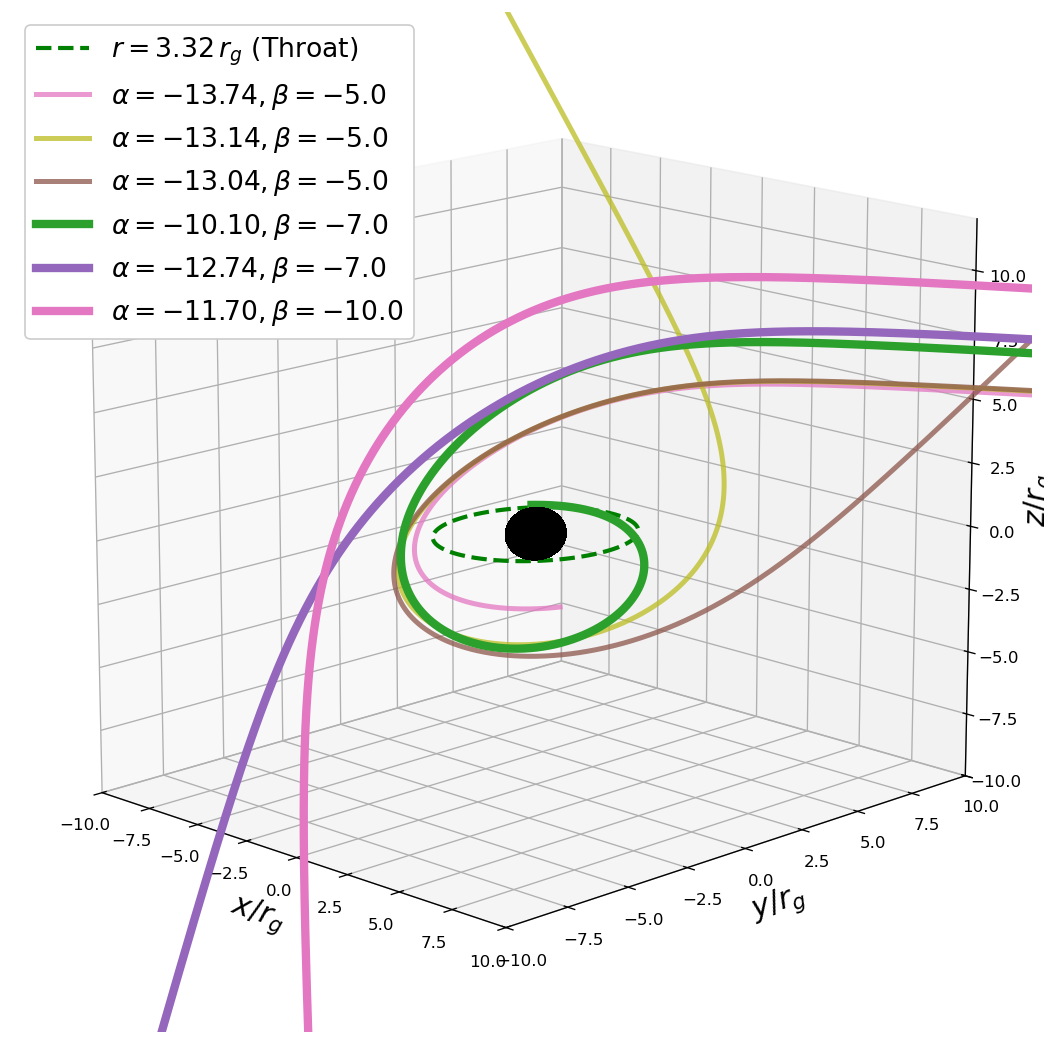

Legend entries:
  $r=3.32\,r_g\ \mathrm{(Throat)}$
  $\alpha = -13.74, \beta = -5.0$
  $\alpha = -13.14, \beta = -5.0$
  $\alpha = -13.04, \beta = -5.0$
  $\alpha = -10.10, \beta = -7.0$
  $\alpha = -12.74, \beta = -7.0$
  $\alpha = -11.70, \beta = -10.0$


In [74]:
import re
import matplotlib.pyplot as plt

# Static (non-interactive) reproduction of Cell 11 content
fig_static = plt.figure(figsize=(10, 8.8), dpi=120)
ax = fig_static.add_subplot(111, projection='3d')

# Black hole sphere
ax.plot_surface(
    bh_x, bh_y, bh_z,
    color='black', alpha=1.0, linewidth=0, antialiased=False
)

# Throat ring
ax.plot(
    throat_x, throat_y, throat_z,
    color='green', linewidth=2.5, linestyle='--',
    label=fr'$r={r_throat:.2f}\,r_g\ \mathrm{{(Throat)}}$'
)

def to_latex_ab(label: str) -> str:
    """Convert to LaTeX and format alpha with two decimals."""
    m = re.search(
        r'α\s*=\s*([-+]?\d*\.?\d+)\s*,\s*β\s*=\s*([-+]?\d*\.?\d+)',
        label,
    )
    if m:
        alpha_val = float(m.group(1))
        beta_val = float(m.group(2))
        return rf'\alpha = {alpha_val:.2f}, \beta = {beta_val:.1f}'
    return label.replace('α', r'\alpha').replace('β', r'\beta')

# Group 2 - spiral-infall (same as Cell 11)
for i, (fname, label) in enumerate(spiral_ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    mask = np.sqrt(x**2 + y**2 + z**2) < 30
    ax.plot(
        x[mask], y[mask], z[mask],
        color=spiral_colors[i], linewidth=3, alpha=0.75,
        label=fr'${to_latex_ab(label)}$'
    )

# Group 3 - 3D helical trajectories (same as Cell 11)
for i, (fname, label) in enumerate(helix_ray_files):
    data = load_ray(fname)
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    mask = np.sqrt(x**2 + y**2 + z**2) < 30
    ax.plot(
        x[mask], y[mask], z[mask],
        color=helix_colors[i], linewidth=5,
        label=fr'${to_latex_ab(label)}$'
    )

# Axes style (math font + same ranges/aspect as Cell 11)
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 12)
ax.set_box_aspect((1.1, 1.25, 1.1))
ax.set_xlabel(r'$x / r_g$', fontsize=AXIS_LABEL_FONT_SIZE)
ax.set_ylabel(r'$y / r_g$', fontsize=AXIS_LABEL_FONT_SIZE)
ax.set_zlabel(r'$z / r_g$', fontsize=AXIS_LABEL_FONT_SIZE)

# Approximate camera view of Cell 11
ax.view_init(elev=15, azim=-45)

# Legend in LaTeX format
legend = ax.legend(loc='upper left', fontsize=LEGEND_FONT_SIZE, framealpha=1)
plt.tight_layout()
plt.show()

# Check legend content is LaTeX text and consistent
print('Legend entries:')
for txt in legend.get_texts():
    print(' ', txt.get_text())